In [1]:
import numpy as np
import pandas as pd
import umap



2025-05-21 13:21:34.112011: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-21 13:21:34.123631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747833694.136707 2386917 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747833694.140591 2386917 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747833694.151470 2386917 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

141 before remove
141 after remove


/workspace/tools/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


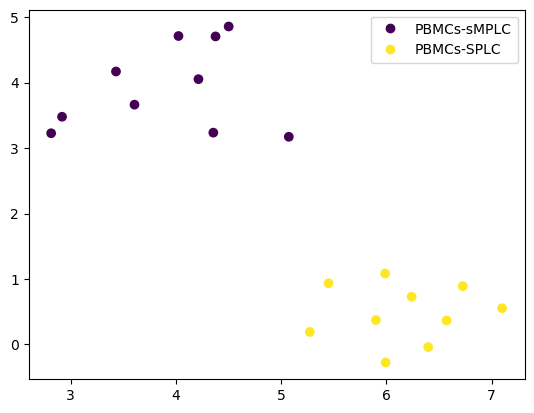

In [5]:

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
plt.cla()
df = pd.read_csv("./df_VJ_all.csv")
df.fillna(0,inplace=True)
col_list = df.columns.tolist()
col_list[0]="sample"
df.columns = col_list
arrange_dict = {}
arrange_list = ["PBMCs-sMPLC","PBMCs-SPLC"]
for cate,i in zip(arrange_list,range(len(arrange_list))):
    arrange_dict[cate] = i
arrange_dict
colorlist=[[x] for x in df["Category"].map(arrange_dict)]
param_begin = df.columns.tolist().index("IGHV1-3;IGHJ2")
param_over = df.columns.tolist().index("TRAV14DV4;TRDJ3")
use_cols = df.columns[param_begin:param_over].tolist()
print(str(len(use_cols))+" before remove")
remove_list = []
for remove_item in remove_list:
    use_cols.remove(remove_item)
print(str(len(use_cols))+" after remove")
df[use_cols].values[0]
bio_data=np.array(df[df.columns[param_begin:param_over]].values,dtype=np.float32)
scaled_bio_data = StandardScaler().fit_transform(bio_data)
reducer = umap.UMAP(n_neighbors=6,min_dist=0.01,n_epochs =100,random_state=8)
embedding = reducer.fit_transform(scaled_bio_data)
scatter = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c = colorlist)
plt.legend(handles=scatter.legend_elements()[0], labels=arrange_dict.keys())
# for i in range(len(embedding[:, 0])):
#     plt.annotate(df["sample"].values.tolist()[i], xy = (embedding[:, 0][i], embedding[:, 1][i]), xytext = (embedding[:, 0][i]+0.1, embedding[:, 1][i]+0.1))
# plt.xticks([])
# plt.yticks([])
# df[["sample","category"]+df.columns[param_begin:param_over].tolist()].to_csv("1.csv",index=False)
plt.savefig("./VJ_p005.png",bbox_inches='tight',dpi=300)

In [3]:
df

,sample,category,Total_Receptor_RNA,Reads/UMI,MigsGoodTotal,ReadsGoodTotal,DecodedReads,TRA_percent_reads_all,TRB_percent_reads_all,TRD_percent_reads_all,...,IGHG12-IGHG34_CSR0,IGHG12-IGHG34_CSR1,IGHG12-IGHM_IGHD_CSR0,IGHG12-IGHM_IGHD_CSR1,IGHG34-IGHM_IGHD_CSR0,IGHG34-IGHM_IGHD_CSR1,IGHA_observed_as_other_isotype,IGHG12_observed_as_other_isotype,IGHG34_observed_as_other_isotype,IGHM_IGHD_observed_as_other_isotype
0,SZ_W_QHG,patient,575573,7.975683,639384,5099524,5760269,28.144996,38.120447,1.609005,...,0.000235,0.000043,0.004473,0.000519,0.000000,0.000000,0.018570,0.037037,0.011236,0.001358149
1,SZ_W_ZXL,patient,504796,9.881113,555686,5490796,6161585,22.581994,27.006157,0.736337,...,0.000804,0.000445,0.009507,0.001157,0.004730,0.000178,0.036145,0.097159,0.116883,0.011989193
2,SZ_W_CXY,patient,265438,17.874143,283687,5070662,5672107,36.150815,35.360046,0.233199,...,0.001983,0.000605,0.066376,0.001615,0.062277,0.000202,0.019250,0.039506,0.044586,0.008240427
3,SZ_W_910,patient,232899,22.227788,240434,5344316,5872335,15.212603,21.474115,1.242169,...,0.003825,0.001184,0.008041,0.001522,0.000565,0.000423,0.037357,0.059519,0.060150,0.007340091
4,SZ_W_918XCR,patient,182539,32.816718,188322,6180110,6788597,14.427054,18.228433,0.230636,...,0.001259,0.000555,0.002972,0.001666,0.000000,0.000000,0.061889,0.118577,0.131148,0.014044501
5,SZ_W_920,patient,106847,45.232208,110203,4984725,5439134,33.237246,39.596807,1.264425,...,0.000000,0.000000,0.006595,0.001106,0.000000,0.000000,0.015332,0.031579,0.000000,0.006809339
6,SZ_W_928WYL,patient,188683,27.008077,194496,5252963,5769327,22.230408,25.453803,0.659837,...,0.000832,0.000362,0.004576,0.001688,0.000000,0.000000,0.042886,0.100604,0.046154,0.0102183
7,SZ_W_928,patient,115609,42.590833,119780,5101530,5583460,19.278776,29.342006,1.166864,...,0.000000,0.000000,0.014212,0.004200,0.000000,0.000000,0.052267,0.097297,0.125000,0.023979261
8,SZ_W_929,patient,169705,28.292383,175431,4963361,5441666,20.104888,23.586812,0.512654,...,0.000960,0.000274,0.004608,0.002053,0.000480,0.000274,0.041783,0.103940,0.106061,0.020555767
9,SZ_W_930MWL,patient,123218,37.755566,128452,4849778,5317005,23.021799,23.318833,1.554968,...,0.000959,0.000181,0.003769,0.001808,0.000685,0.000181,0.029859,0.083503,0.111111,0.009891808


In [11]:
# df["Age"]


NameError: name 'df' is not defined

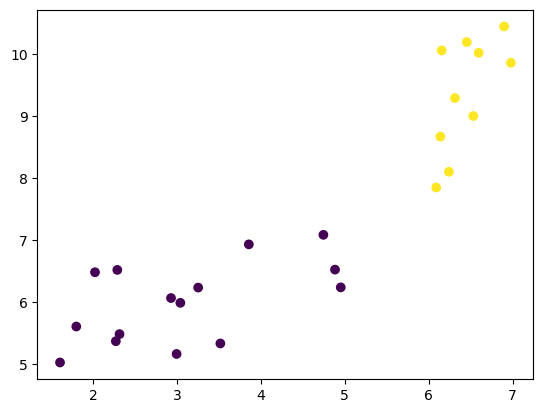

In [8]:

# bio_data=bio_data/bio_data.max()
scaled_bio_data = StandardScaler().fit_transform(bio_data)
reducer = umap.UMAP(n_neighbors=5,min_dist=0.01,n_epochs =50)
embedding = reducer.fit_transform(scaled_bio_data)
scatter = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c = colorlist)
# for i in range(len(embedding[:, 0])):
#     plt.annotate(df["Group2"].values.tolist()[i], xy = (embedding[:, 0][i], embedding[:, 1][i]), xytext = (embedding[:, 0][i]+0.1, embedding[:, 1][i]+0.1)) 

In [29]:
embedding.shape

(71, 2)

In [15]:
df.to_csv("48.csv",index=False)

In [33]:
from statsmodels.stats.multitest import fdrcorrection as fdr
df = pd.read_csv("diversityparam.csv_Age_P_1.csv")
pvalues = np.array(df[df.columns[1:]].values[0])
p_flag = ["P_flag"]
for values in pvalues:
    if values>0.05:
        p_flag.append("False")
    else:
        p_flag.append("True")

In [34]:
res = fdr(pvals=pvalues)
count = 0
for i in res[1]:
    if i<=0.05:
        count+=1
print(count)
print(res[0],"\n",res[1])
print("After FDR Correction max Pvalue:",res[1].max())

24
[False  True False False  True  True False False  True False False  True
  True False  True  True  True False  True  True  True False False False
 False False False False  True False False False  True False False False
  True  True  True  True  True False False  True  True  True  True  True] 
 [0.1236     0.0146688  0.0606144  0.21250909 0.0013896  0.0036504
 0.35003077 0.08565333 0.03650087 0.11809714 0.25878857 0.0013896
 0.0067936  0.3108     0.009513   0.01464253 0.00405785 0.1236
 0.00362928 0.01472686 0.01464253 0.59899535 0.9514     0.61069091
 0.53868    0.35003077 0.88708085 0.5502439  0.00425829 0.35003077
 0.08191385 0.87787826 0.04026    0.22023529 0.728      0.59899535
 0.00127584 0.02467636 0.00274667 0.00127584 0.00127584 0.21195
 0.17218065 0.00127584 0.01464253 0.0036504  0.0013896  0.00127584]
After FDR Correction max Pvalue: 0.9514


In [35]:
fdr_pvalues = ["fdr_pvalues"]
fdr_pvalues += res[0].tolist()
fdr_flag = ["fdr_flag"]
fdr_flag += res[1].tolist()
map(str,fdr_flag)
df.loc[len(df.index)] = p_flag
df.loc[len(df.index)] = fdr_pvalues
df.loc[len(df.index)] = fdr_flag
df.to_csv("fdr.csv")